In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargamos todos los conjuntos de datos: 

df_dia = pd.read_csv("./files/productos_dia_con_categorias.csv", index_col = 0)
df_precios = pd.read_csv("./files/precios_productos.csv", index_col = 0)


In [3]:
df_precios.head()

,price,reference_price,product_id,reference_unit,insert_date
6837303,"0,7","0,7",9b1d806ddaed2a3b4c842c361e9171a8,ud,2022-06-08 00:00:00
5137438,"3,19","10,63",baf038a3f001812899adb8beaf4e0ec7,kg,2022-02-10 00:00:00
6005999,"3,99","15,96",ca2fc753e5ea44e8c95888983c1dafe1,l,2022-04-11 00:00:00
6995217,"3,39","5,22",48c959cc94d6d82d1151189b2abe9e83,l,2022-06-19 00:00:00
5760664,"2,79","0,47",8904722366039ba8f147e2e75a5d1ce1,ud,2022-03-25 00:00:00


In [4]:
df_dia.head(2)

,supermarket,name,description,product_id,categoria,subcategoria
Unnamed: 0,,,,,,
2362486,dia-es,MISTOL lavavajillas mano original botella 900 ml,NaN,9e2fda45e63337294f2a604178823026,cuidado del hogar,lavavajillas
2362487,dia-es,DIA lavavajillas máquina premium todo en uno e...,NaN,244994c762813d38881cb118742152a2,cuidado del hogar,lavavajillas


In [5]:
df_dia.duplicated().sum()

np.int64(7)

In [6]:
df_precios.head(2)

,price,reference_price,product_id,reference_unit,insert_date
6837303,"0,7","0,7",9b1d806ddaed2a3b4c842c361e9171a8,ud,2022-06-08 00:00:00
5137438,"3,19","10,63",baf038a3f001812899adb8beaf4e0ec7,kg,2022-02-10 00:00:00


In [7]:
df_precios.duplicated().sum()

np.int64(0)

In [8]:
df_3 = df_dia.merge(df_precios, on =["product_id"], how = "right")
df_3.head(2)


,supermarket,name,description,product_id,categoria,subcategoria,price,reference_price,reference_unit,insert_date
0,dia-es,DIA SUPER PACO guantes satinados talla S bolsa...,NaN,9b1d806ddaed2a3b4c842c361e9171a8,cuidado del hogar,utensilios de limpieza,"0,7","0,7",ud,2022-06-08 00:00:00
1,dia-es,KELLOGGS cereales special k con frutas rojas c...,NaN,baf038a3f001812899adb8beaf4e0ec7,despensa,desayunos y dulces,"3,19","10,63",kg,2022-02-10 00:00:00


In [9]:
df_3.shape

(1264512, 10)

In [10]:
df_final2 = df_precios.merge(df_dia, on =["product_id"], how = "right")
df_final2.sample(5)

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,description,categoria,subcategoria
1241775,"1,69","11,27",108bdf56903d4f69455177af12293e6e,kg,2022-06-15 00:00:00,dia-es,LA EXPLANADA aceitunas rellenas de anchoa lata...,NaN,despensa,aperitivos
889461,"0,35","1,06",77d10e042805a2b803831e3f6db93bf5,l,2022-03-10 00:00:00,dia-es,SUREÑA cerveza lata 33 cl,NaN,bebidas,cervezas
197516,"3,95","15,8",07c30a02deff48d6bf1ade994aefbb83,kg,2022-06-16 00:00:00,dia-es,VALOR cacao puro 100% natural en polvo bote 25...,NaN,despensa,desayunos y dulces
726816,"1,05","10,5",265b009843ba5c8c8693055b5ed4e310,kg,2021-09-14 00:00:00,dia-es,MIDEL golosinas gomy bag moras bolsa 100 gr,NaN,despensa,desayunos y dulces
781771,"2,0","2,0",dc1496c36cd7101bee0269efaf730aa2,ud,2021-08-31 00:00:00,dia-es,ZUM trampa para cucarachas 1 ud,NaN,cuidado del hogar,insecticidas


In [11]:
df_final2.shape

(1264539, 10)

In [12]:
df_final2.duplicated().sum()

np.int64(1101)

In [13]:
df_final2.columns

Index(['price', 'reference_price', 'product_id', 'reference_unit',
       'insert_date', 'supermarket', 'name', 'description', 'categoria',
       'subcategoria'],
      dtype='object')

In [14]:
df_final2.head(2)

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,description,categoria,subcategoria
0,"1,59","1,59",9e2fda45e63337294f2a604178823026,ud,2021-08-14 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,NaN,cuidado del hogar,lavavajillas
1,"1,59","1,59",9e2fda45e63337294f2a604178823026,ud,2021-08-17 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,NaN,cuidado del hogar,lavavajillas


In [15]:
## Gestion de nulos
df_final2.isnull().sum()



price                   29
reference_price         29
product_id               0
reference_unit        1643
insert_date             27
supermarket              0
name                     0
description        1264539
categoria                0
subcategoria             0
dtype: int64

In [16]:
# eliminar columnas que no aportan informacion
df_final2.drop(columns = ["description"], inplace = True)

In [17]:
df_final2.drop_duplicates(subset=["product_id"], keep = "first", inplace = True)

# Cleaning

In [18]:
df_final2['reference_price']

0           1,59
10          0,11
42          0,24
215         0,44
384         5,38
           ...  
1264332    13,75
1264335    12,75
1264337     1,58
1264338    15,45
1264361    16,58
Name: reference_price, Length: 9496, dtype: object

**Cambiar tipo de dato**

In [19]:
columnas = ["price", "reference_price"]

for i in columnas: 
    df_final2[i] = df_final2[i].str.replace(",", ".")

In [20]:
df_final2.head()

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria
0,1.59,1.59,9e2fda45e63337294f2a604178823026,ud,2021-08-14 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,cuidado del hogar,lavavajillas
10,3.99,0.11,244994c762813d38881cb118742152a2,ud,2021-08-22 00:00:00,dia-es,DIA lavavajillas máquina premium todo en uno e...,cuidado del hogar,lavavajillas
42,9.99,0.24,8a5398b602e44b93a0c0a4a7b9d22b84,ud,2021-10-23 00:00:00,dia-es,FAIRY lavavajillas máquina platinum azul en cá...,cuidado del hogar,lavavajillas
215,7.99,0.44,2cd7ea87b1963adb51d8e1295f6c14d3,ud,2022-07-03 00:00:00,dia-es,FAIRY lavavajillas máquina platinum plus limón...,cuidado del hogar,lavavajillas
384,2.69,5.38,4abac3d30922f81012d7ae0c2cd955f2,l,2022-02-07 00:00:00,dia-es,FAIRY lavavajillas mano concentrado aloe vera ...,cuidado del hogar,lavavajillas


In [21]:
df_final2.dtypes

price              object
reference_price    object
product_id         object
reference_unit     object
insert_date        object
supermarket        object
name               object
categoria          object
subcategoria       object
dtype: object

In [22]:
## convertir a float las columnas de precio
for i in columnas: 
    df_final2[i] = df_final2[i].astype(float)

In [23]:
#comprobar que se han convertido correctamente
df_final2.dtypes

price              float64
reference_price    float64
product_id          object
reference_unit      object
insert_date         object
supermarket         object
name                object
categoria           object
subcategoria        object
dtype: object

In [24]:
#ver los duplicaos de una columnas
df_final2[df_final2.duplicated(subset = ["product_id"], keep = False)].sort_values("product_id")

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria


**Unidades** 

In [25]:
#explorar los datos de las unidades
df_final2.reference_unit.unique()

array(['ud', 'l', 'kg', nan, 'lavado', 'm'], dtype=object)

In [26]:
df_sin_duplicados = df_final2.drop_duplicates(subset=['product_id'], keep='first')


In [27]:
#explorando las unidades de tipo m 
df_sin_duplicados[df_final2["reference_unit"] == "m"]


,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria
249989,1.25,1.25,e294e65ec57bfbb28c15518eca99f417,m,2021-09-08 00:00:00,dia-es,BONTE seda dental menta y cera caja 50 metros,cuidado personal,cuidado bucal
250129,2.59,0.05,8f100f0facbd16bbb68b6f66982493ac,m,2021-08-18 00:00:00,dia-es,DIA SUPER PACO papel de aluminio 50 m.,cuidado del hogar,conservacion de alimentos
788920,3.39,0.07,b371a0ddd871806398c24d927b7e2d84,m,2022-03-08 00:00:00,dia-es,COLGATE Total seda dental blíster 50 mt.,cuidado personal,cuidado bucal
789031,1.35,0.27,87fcd5baf3f72b9e542bee26c965f32f,m,2021-11-13 00:00:00,dia-es,DR. SOS esparadrapo 5m x 2.5cm + dispensador c...,cuidado personal,botiquin
789163,3.10,0.10,d70f3d9444c448b08f0b5b1643c717f0,m,2021-11-20 00:00:00,dia-es,ALBAL papel aluminio 30 m,cuidado del hogar,conservacion de alimentos
789284,1.85,0.09,765e241fa3a6efb741bdc09d340bd4e7,m,2021-12-30 00:00:00,dia-es,ALBAL film transparente corte fácil 20 m,cuidado del hogar,conservacion de alimentos
789400,1.85,0.06,4f6c2b6558ac5fe616c9d87a44594094,m,2022-03-03 00:00:00,dia-es,ALBAL film transparente 30 m,cuidado del hogar,conservacion de alimentos
929492,1.49,1.49,3df76ac20f3b61e94708b4043ee78c5a,m,2021-10-16 00:00:00,dia-es,DIA SUPER PACO papel de aluminio 30 m.,cuidado del hogar,conservacion de alimentos
936793,0.99,0.99,2bb62eac21737457e97cd759fd0426a3,m,2021-10-11 00:00:00,dia-es,DIA SUPER PACO film transparente 80 m.,cuidado del hogar,conservacion de alimentos
1085899,1.99,0.07,9284f06032f2fec8fcbf764a20f275c3,m,2021-12-10 00:00:00,dia-es,ALUMFIX papel aluminio 30 m,cuidado del hogar,conservacion de alimentos


In [28]:
#explorando las unidades de tipo lavado
df_final2[df_final2["reference_unit"] == "lavado"]

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria
45246,5.10,0.14,06babee2a8fbb7f86eb1f3db7208bc85,lavado,2021-10-05 00:00:00,dia-es,DIA detergente máquina polvo maleta 36 cacitos,cuidado del hogar,cuidado de la ropa
320190,7.99,0.27,5755660c54cdfff4e770c4930c57c2fa,lavado,2021-10-12 00:00:00,dia-es,FINISH lavavajillas máquina todo en uno plus p...,cuidado del hogar,lavavajillas
320353,14.99,0.25,06c7edcc40f622d29ed32d309f2edd59,lavado,2022-02-03 00:00:00,dia-es,FAIRY lavavajillas máquina todo en uno en cáps...,cuidado del hogar,lavavajillas
320546,6.69,0.45,9e16d7515c428de79f3b8ea77ca09cec,lavado,2022-04-12 00:00:00,dia-es,FINISH Quantum lavavajillas máquina powerball ...,cuidado del hogar,lavavajillas
320719,6.49,0.30,2d1b46b764a97542c076005156561044,lavado,2021-12-18 00:00:00,dia-es,FAIRY lavavajillas máquina original en cápsula...,cuidado del hogar,lavavajillas
...,...,...,...,...,...,...,...,...,...
1210877,11.49,0.21,f6503afe219b07bf91fa8579cceeb731,lavado,2022-08-14 00:00:00,dia-es,ARIEL detergente en polvo básico Ariel 55 lavados,cuidado del hogar,cuidado de la ropa
1212167,9.29,0.37,5c6692f6649083afa2a4815946d9a250,lavado,2022-06-10 00:00:00,dia-es,ARIEL detergente máquina líquido fresh sensati...,cuidado del hogar,cuidado de la ropa
1213644,11.95,0.46,3f4c058dd7b860ed807ba66d6f91d31c,lavado,2022-06-10 00:00:00,dia-es,ARIEL Pods detergente máquina all in 1 en cáps...,cuidado del hogar,cuidado de la ropa
1242668,9.99,0.27,0ed14db8955f0e430a63e3a967a65894,lavado,2022-06-16 00:00:00,dia-es,WIPP EXPRESS detergente máquina líquido limpio...,cuidado del hogar,cuidado de la ropa


**Para quitar la hora**



In [29]:
## quittamos la hora de la fecha porque no aporta informacion, siempre es la misma
df_final2["insert_date"]

0          2021-08-14 00:00:00
10         2021-08-22 00:00:00
42         2021-10-23 00:00:00
215        2022-07-03 00:00:00
384        2022-02-07 00:00:00
                  ...         
1264332    2022-08-13 00:00:00
1264335    2022-08-14 00:00:00
1264337    2022-08-16 00:00:00
1264338    2022-08-14 00:00:00
1264361    2022-08-15 00:00:00
Name: insert_date, Length: 9496, dtype: object

In [30]:
#solo me quedo con la fecha, hago un split con el espacio y me quedo con la primera parte
df_final2["date"] = df_final2["insert_date"].str.split(" ").str[0]
df_final2.head()

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria,date
0,1.59,1.59,9e2fda45e63337294f2a604178823026,ud,2021-08-14 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,cuidado del hogar,lavavajillas,2021-08-14
10,3.99,0.11,244994c762813d38881cb118742152a2,ud,2021-08-22 00:00:00,dia-es,DIA lavavajillas máquina premium todo en uno e...,cuidado del hogar,lavavajillas,2021-08-22
42,9.99,0.24,8a5398b602e44b93a0c0a4a7b9d22b84,ud,2021-10-23 00:00:00,dia-es,FAIRY lavavajillas máquina platinum azul en cá...,cuidado del hogar,lavavajillas,2021-10-23
215,7.99,0.44,2cd7ea87b1963adb51d8e1295f6c14d3,ud,2022-07-03 00:00:00,dia-es,FAIRY lavavajillas máquina platinum plus limón...,cuidado del hogar,lavavajillas,2022-07-03
384,2.69,5.38,4abac3d30922f81012d7ae0c2cd955f2,l,2022-02-07 00:00:00,dia-es,FAIRY lavavajillas mano concentrado aloe vera ...,cuidado del hogar,lavavajillas,2022-02-07


In [31]:
#ahora convierto la fecha en formato datetime
df_final2["date"] = pd.to_datetime(df_final2["date"])

In [32]:
#compruebo que se ha convertido correctamente
df_final2.dtypes

price                     float64
reference_price           float64
product_id                 object
reference_unit             object
insert_date                object
supermarket                object
name                       object
categoria                  object
subcategoria               object
date               datetime64[ns]
dtype: object

In [33]:
# otra opción usando una función: 

def separar_fecha(x):
    return x.split(" ")[0]

In [34]:
#df_final2["date2"] = df_final2["insert_date"].apply(separar_fecha)
#df_final2.head()

**Para calcular la diferencia de precios**

In [35]:
def sacar_diferencia(precio, precio_referencia):
    return precio_referencia - precio

In [36]:
df_final2["difference"] = df_final2.apply(lambda x: sacar_diferencia(x["price"], x["reference_price"]), axis = 1)
df_final2.head()

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria,date,difference
0,1.59,1.59,9e2fda45e63337294f2a604178823026,ud,2021-08-14 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,cuidado del hogar,lavavajillas,2021-08-14,0.00
10,3.99,0.11,244994c762813d38881cb118742152a2,ud,2021-08-22 00:00:00,dia-es,DIA lavavajillas máquina premium todo en uno e...,cuidado del hogar,lavavajillas,2021-08-22,-3.88
42,9.99,0.24,8a5398b602e44b93a0c0a4a7b9d22b84,ud,2021-10-23 00:00:00,dia-es,FAIRY lavavajillas máquina platinum azul en cá...,cuidado del hogar,lavavajillas,2021-10-23,-9.75
215,7.99,0.44,2cd7ea87b1963adb51d8e1295f6c14d3,ud,2022-07-03 00:00:00,dia-es,FAIRY lavavajillas máquina platinum plus limón...,cuidado del hogar,lavavajillas,2022-07-03,-7.55
384,2.69,5.38,4abac3d30922f81012d7ae0c2cd955f2,l,2022-02-07 00:00:00,dia-es,FAIRY lavavajillas mano concentrado aloe vera ...,cuidado del hogar,lavavajillas,2022-02-07,2.69


## Análisis de categorías

In [37]:
df_final2['categoria'].unique()

array(['cuidado del hogar', 'cuidado del hogar de limpieza', 'mascotas',
       'platos preparados', 'al dia', 'despensa', 'bebidas', 'bodega',
       'bebe', 'congelados', 'cuidado personal', 'frescos',
       'dulces de navidad'], dtype=object)

In [38]:
df_final2['subcategoria'].unique()

array(['lavavajillas', 'bano', 'perros', 'hogar', 'ambientadores',
       'calzado', 'insecticidas', 'gatos', 'nuestra cocina al dia',
       'gazpachos y salmorejos', 'charcuteria y quesos',
       'desayunos y dulces', 'conservas', 'pastas harinas y masas',
       'aceites vinagres y alinos', 'cocina internacional',
       'bebidas isotonicas y energeticas', 'espumosos', 'panales',
       'utensilios de limpieza', 'dieteticos', 'helados', 'afeitado',
       'botiquin', 'depilacion', 'bano e higiene personal',
       'cuidado bucal', 'cuidado corporal', 'toallitas', 'cuidado intimo',
       'cuidado del bebe', 'sopas', 'pan', 'sal y especias',
       'cuidado de la ropa', 'pescado y marisco', 'cocina', 'aguas',
       'refrescos', 'cervezas', 'zumos', 'batidos y horchata', 'vino',
       'vinos de mesa sangrias y tintos de verano', 'alcoholes', 'frutas',
       'aperitivos', 'pescado', 'verduras', 'bocadillos y sandwich',
       'carne', 'croquetas y aperitivos', 'verduras y hortaliza

In [39]:
df_final2.head()

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria,date,difference
0,1.59,1.59,9e2fda45e63337294f2a604178823026,ud,2021-08-14 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,cuidado del hogar,lavavajillas,2021-08-14,0.00
10,3.99,0.11,244994c762813d38881cb118742152a2,ud,2021-08-22 00:00:00,dia-es,DIA lavavajillas máquina premium todo en uno e...,cuidado del hogar,lavavajillas,2021-08-22,-3.88
42,9.99,0.24,8a5398b602e44b93a0c0a4a7b9d22b84,ud,2021-10-23 00:00:00,dia-es,FAIRY lavavajillas máquina platinum azul en cá...,cuidado del hogar,lavavajillas,2021-10-23,-9.75
215,7.99,0.44,2cd7ea87b1963adb51d8e1295f6c14d3,ud,2022-07-03 00:00:00,dia-es,FAIRY lavavajillas máquina platinum plus limón...,cuidado del hogar,lavavajillas,2022-07-03,-7.55
384,2.69,5.38,4abac3d30922f81012d7ae0c2cd955f2,l,2022-02-07 00:00:00,dia-es,FAIRY lavavajillas mano concentrado aloe vera ...,cuidado del hogar,lavavajillas,2022-02-07,2.69


In [40]:
def reemplazar(x):
    if x == 'cuidado-del-hogar-de-limpieza':
        return 'cuidado-del-hogar'
    else:
        return x

In [41]:
df_final2["categoria"] = df_final2["categoria"].apply(reemplazar)

In [42]:
df_final2.head(1)

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria,date,difference
0,1.59,1.59,9e2fda45e63337294f2a604178823026,ud,2021-08-14 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,cuidado del hogar,lavavajillas,2021-08-14,0.0


In [43]:
# ¿Qué categoría es la que vende más productos? 
df_final2.groupby(["categoria"]).count()

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,subcategoria,date,difference
categoria,,,,,,,,,,
al dia,731,731,733,731,731,733,733,733,731,731
bebe,282,282,282,282,282,282,282,282,282,282
bebidas,579,579,579,579,579,579,579,579,579,579
bodega,388,388,388,388,388,388,388,388,388,388
congelados,404,404,406,403,404,406,406,406,404,404
cuidado del hogar,784,784,784,784,784,784,784,784,784,784
cuidado del hogar de limpieza,190,190,190,190,190,190,190,190,190,190
cuidado personal,2331,2331,2343,2311,2331,2343,2343,2343,2331,2331
despensa,3142,3142,3147,3139,3142,3147,3147,3147,3142,3142


In [44]:
# lo podemos hacer un size también  que es lo mismo que el count, pero sin darme la información para cada columna. 
df_categoria = df_final2.groupby(["categoria"]).size().reset_index()
df_categoria.columns = ["categoria", "conteo"]
df_categoria.sort_values(by ="conteo", inplace=True, ascending = False)
df_categoria.head(2)

,categoria,conteo
8,despensa,3147
7,cuidado personal,2343


/var/folders/cr/f3dqyy756z9ftxxsrmgtgjjh0000gn/T/ipykernel_20619/1758326271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_categoria, x = "categoria", y = "conteo", palette=sns.color_palette("YlOrBr"))
/var/folders/cr/f3dqyy756z9ftxxsrmgtgjjh0000gn/T/ipykernel_20619/1758326271.py:4: UserWarning: 
The palette list has fewer values (6) than needed (13) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data = df_categoria, x = "categoria", y = "conteo", palette=sns.color_palette("YlOrBr"))


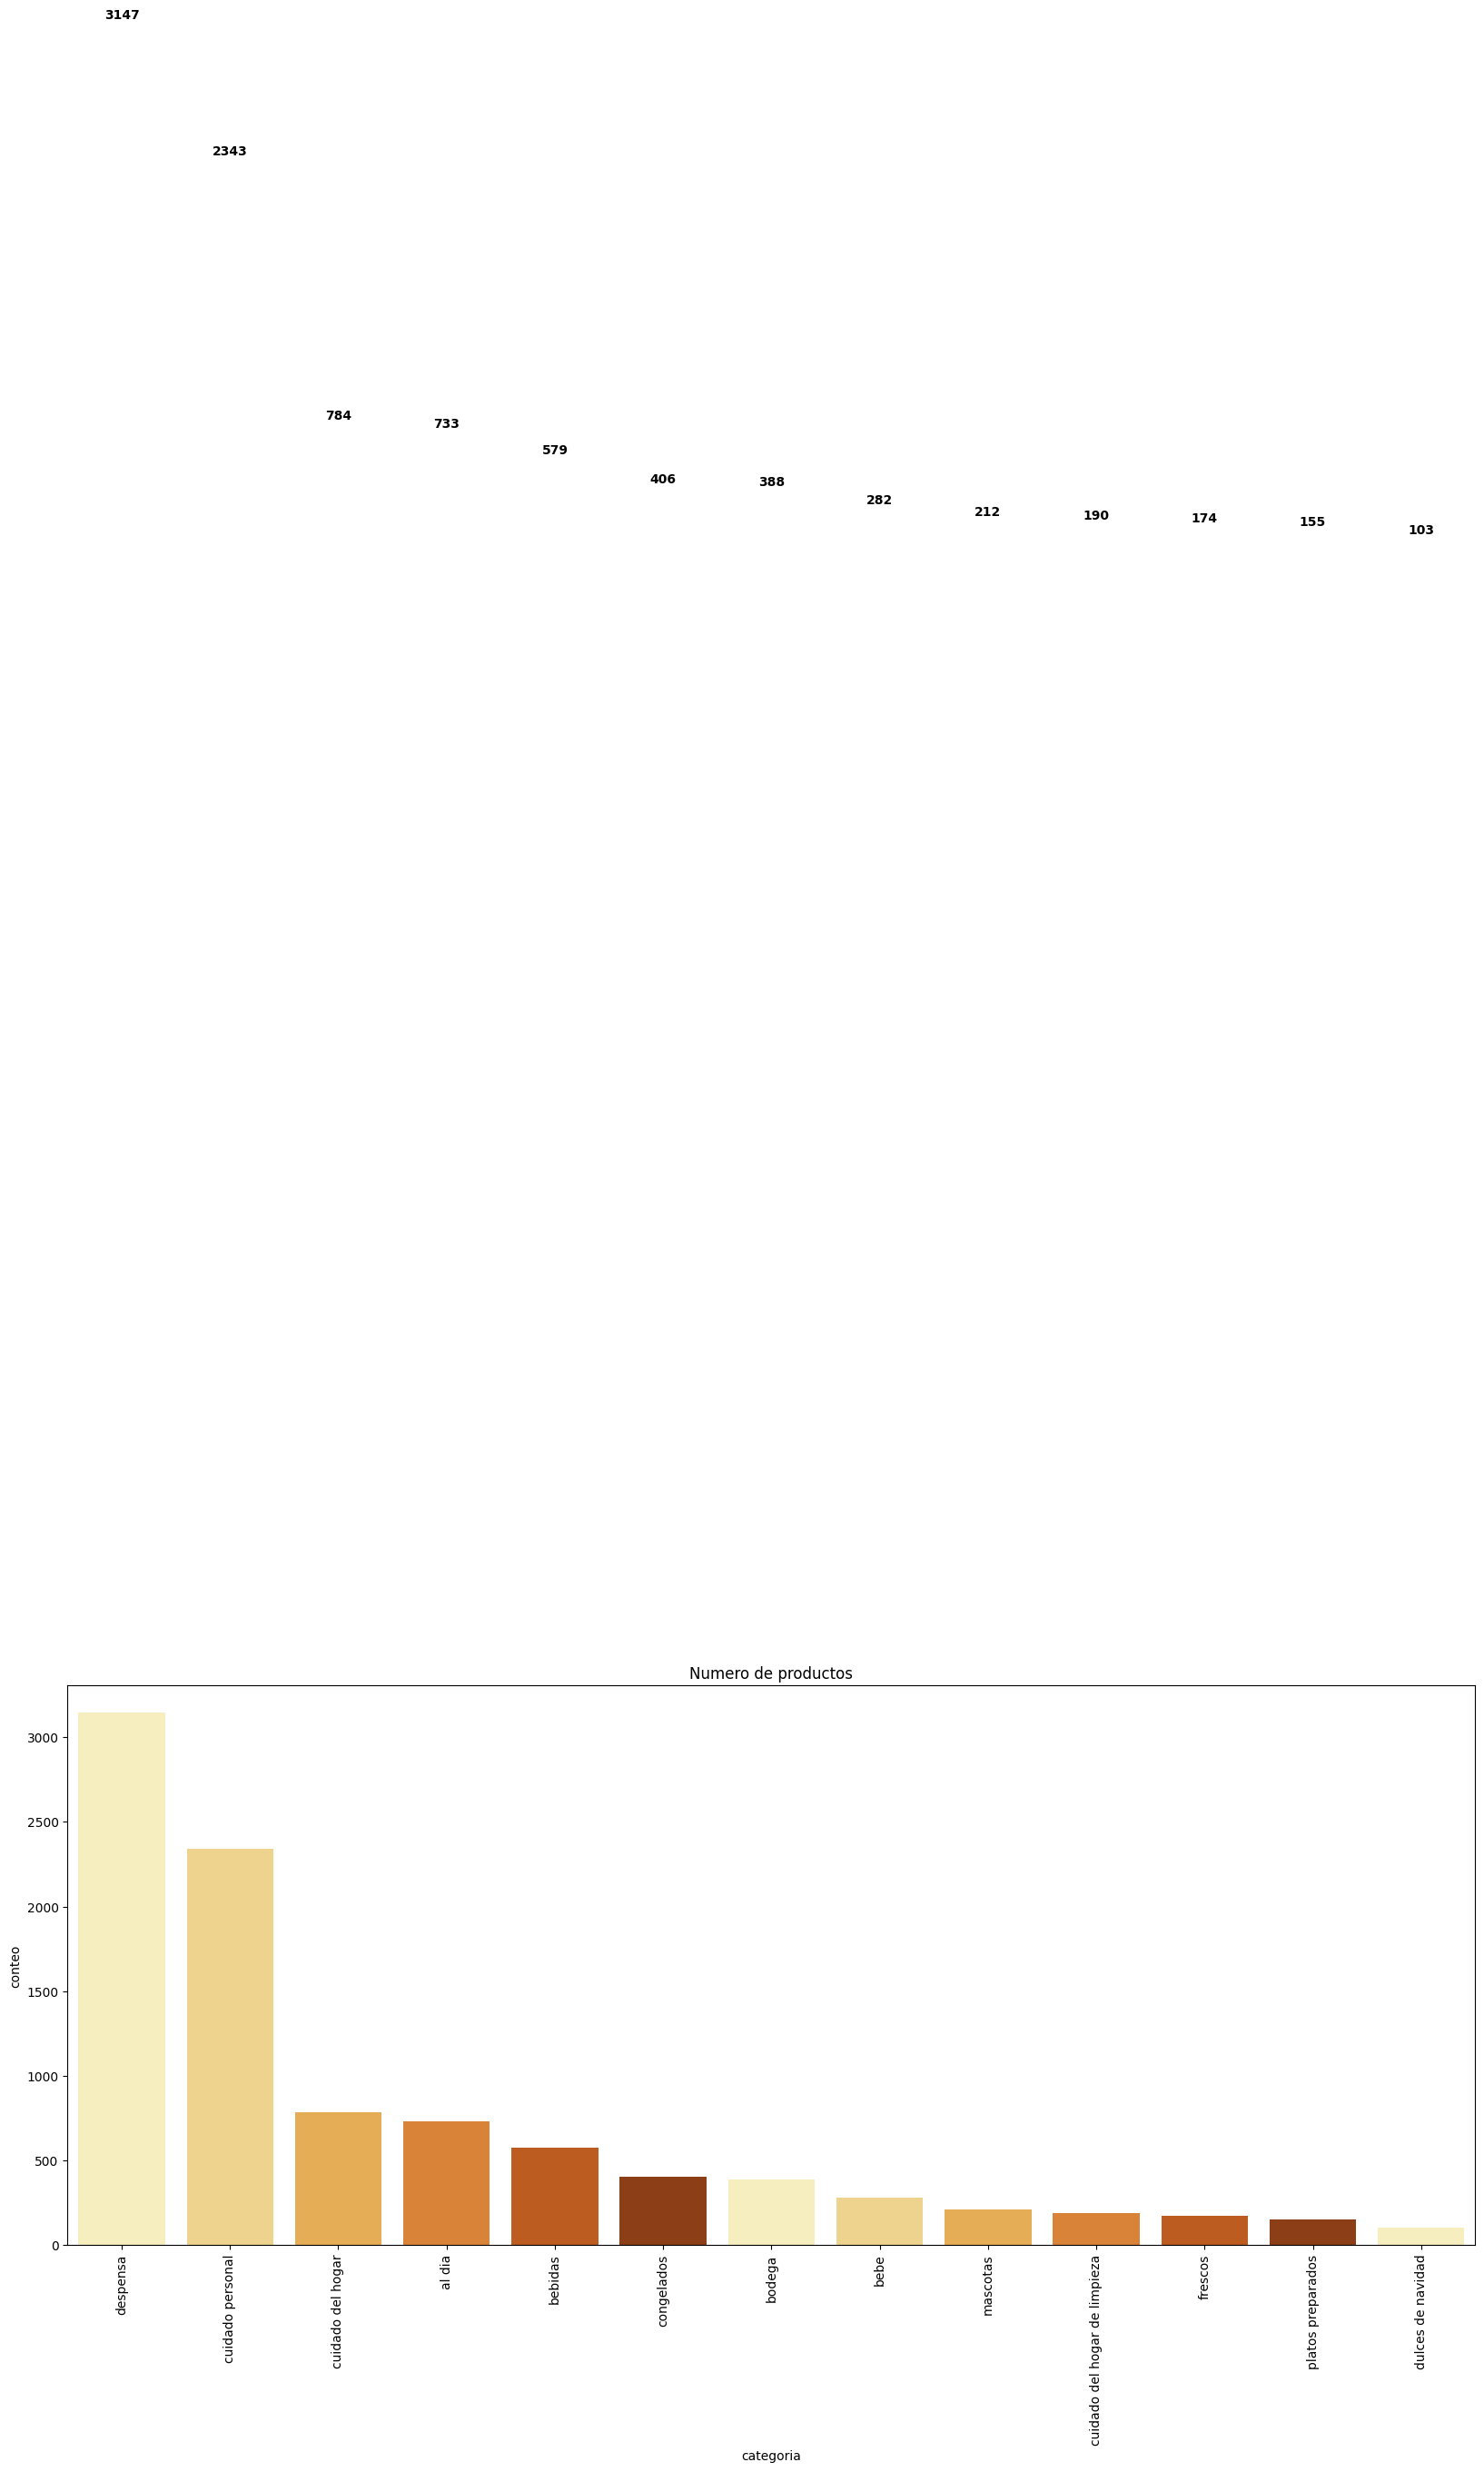

In [45]:
# Como lo veríamos visualmente

plt.figure(figsize =(20,8)) # para establecer el tamaño de la gráfica
sns.barplot(data = df_categoria, x = "categoria", y = "conteo", palette=sns.color_palette("YlOrBr")) 
plt.xticks(rotation=90) # para girar las etiquetas del eje-x
plt.title("Numero de productos")

# para poner etiquetas encima de las barras
for indice, valor in enumerate(df_categoria["conteo"]):
    plt.text(indice, valor + 10000, str(valor),
             horizontalalignment='center', # para colocarlo en el centro de la barra
             fontweight = "bold") 

plt.show();

In [46]:
# 3. Dentro de cada categoría, ¿qué subcategorías son más populares? 
df_categoria_subcategoria = df_final2.groupby(["categoria", "subcategoria"]).size().reset_index()
df_categoria_subcategoria.rename(columns={0:"conteo"}, inplace=True)
df_categoria_subcategoria.sort_values(by = "conteo", ascending=False, inplace=True)
df_categoria_subcategoria.head(2)

,categoria,subcategoria,conteo
56,despensa,desayunos y dulces,1237
44,cuidado personal,bano e higiene personal,1228


In [47]:
#plt.figure(figsize =(20,8))
#sns.barplot(data = df_categoria_subcategoria, x = "categoria", y = "conteo", hue = "subcategoria", palette=sns.color_palette("YlOrBr"))
#plt.xticks(rotation=90)
#plt.show();

In [48]:
#4. ¿Qué categoría es la que tiene los precios más altos? ¿y los mínimos? ¿Cuál es su media? 
df_final2.groupby(["categoria"])["price"].agg(["mean", "max", "min", "median"]).sort_values(by = "mean", ascending = False)

,mean,max,min,median
categoria,,,,
bodega,6.787887,33.84,0.65,4.99
frescos,6.365357,289.00,0.67,2.25
cuidado personal,5.195375,44.99,0.65,3.89
bebe,4.995071,25.74,0.75,3.59
mascotas,4.377547,27.25,0.39,3.29
cuidado del hogar,3.967679,60.00,0.25,2.95
al dia,3.739945,129.00,0.21,2.09
congelados,3.288564,22.89,0.49,2.95
dulces de navidad,2.581942,7.49,0.10,2.19


## Análisis de precios y productos

In [49]:
##Si hay valores extremadamente altos que están afectando la escala, podemos filtrar precios dentro de un rango razonable antes de graficar.

percentile_99 = df_final2['price'].quantile(0.99)
filtered_prices = df_final2[df_final2['price'] <= percentile_99]

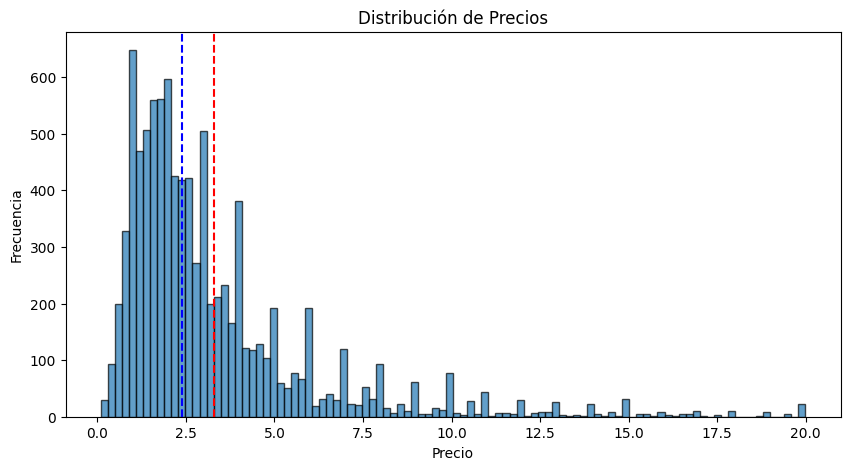

In [50]:
## ¿Existen productos con precios fuera de lo común (outliers)?

plt.figure(figsize=(10, 5))
plt.hist(filtered_prices['price'], bins=100, edgecolor='black', alpha=0.7)
plt.axvline(filtered_prices['price'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(filtered_prices['price'].median(), color='blue', linestyle='--', label='Mediana')
plt.title("Distribución de Precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

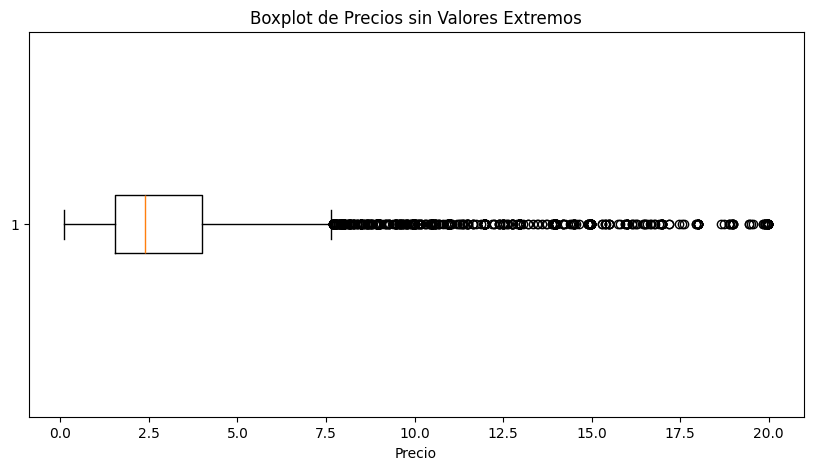

In [51]:
# Graficar boxplot sin los valores extremos
plt.figure(figsize=(10, 5))
plt.boxplot(filtered_prices['price'], vert=False)
plt.title("Boxplot de Precios sin Valores Extremos")
plt.xlabel("Precio")
plt.show()


In [52]:
## - ¿Cuántos productos tienen un precio superior al precio de referencia?

# Filtrar productos cuyo precio es mayor al precio de referencia
productos_mas_caros = df_final2[df_final2['price'] > df_final2['reference_price']]

# Contar cuántos productos cumplen esta condición
cantidad_productos = productos_mas_caros.shape[0]
cantidad_productos

1265

In [53]:
productos_mas_caros.shape


(1265, 11)

In [54]:
## - ¿Qué categorías de productos tienen la mayor y menor variación de precios?

# Agrupa por categoría y calcula la desviación estándar de los precios.
#Ordena por mayor y menor variabilidad para identificar las categorías con más y menos fluctuación.

variacion_precios = df_final2.groupby('categoria')['price'].std().reset_index()
variacion_precios = variacion_precios.rename(columns={'price': 'desviacion_estandar'})

# Ordenar por mayor y menor variabilidad
mayor_variacion = variacion_precios.sort_values(by='desviacion_estandar', ascending=False).head(5)
menor_variacion = variacion_precios.sort_values(by='desviacion_estandar', ascending=True).head(5)

# Mostrar resultados
print("Categorías con mayor variación de precios:")
print(mayor_variacion)

print("\nCategorías con menor variación de precios:")
print(menor_variacion)

Categorías con mayor variación de precios:
           categoria  desviacion_estandar
10           frescos            24.875901
0             al dia             9.260459
3             bodega             5.711432
7   cuidado personal             4.754079
1               bebe             4.419065

Categorías con menor variación de precios:
                        categoria  desviacion_estandar
12              platos preparados             1.128944
6   cuidado del hogar de limpieza             1.282453
8                        despensa             1.578600
2                         bebidas             1.708565
9               dulces de navidad             1.799201


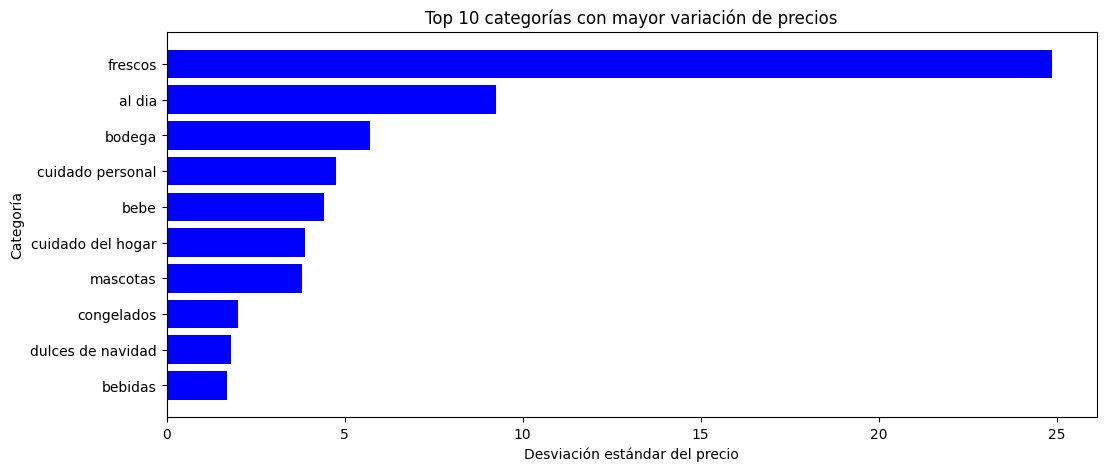

In [55]:

# Ordenar categorías por variabilidad
variacion_precios_sorted = variacion_precios.sort_values(by='desviacion_estandar', ascending=False)

# Graficar las 10 categorías con mayor variación de precios
plt.figure(figsize=(12, 5))
plt.barh(variacion_precios_sorted['categoria'].head(10), variacion_precios_sorted['desviacion_estandar'].head(10), color='blue')
plt.xlabel("Desviación estándar del precio")
plt.ylabel("Categoría")
plt.title("Top 10 categorías con mayor variación de precios")
plt.gca().invert_yaxis()  # Invertir el eje Y para mejor visualización
plt.show()


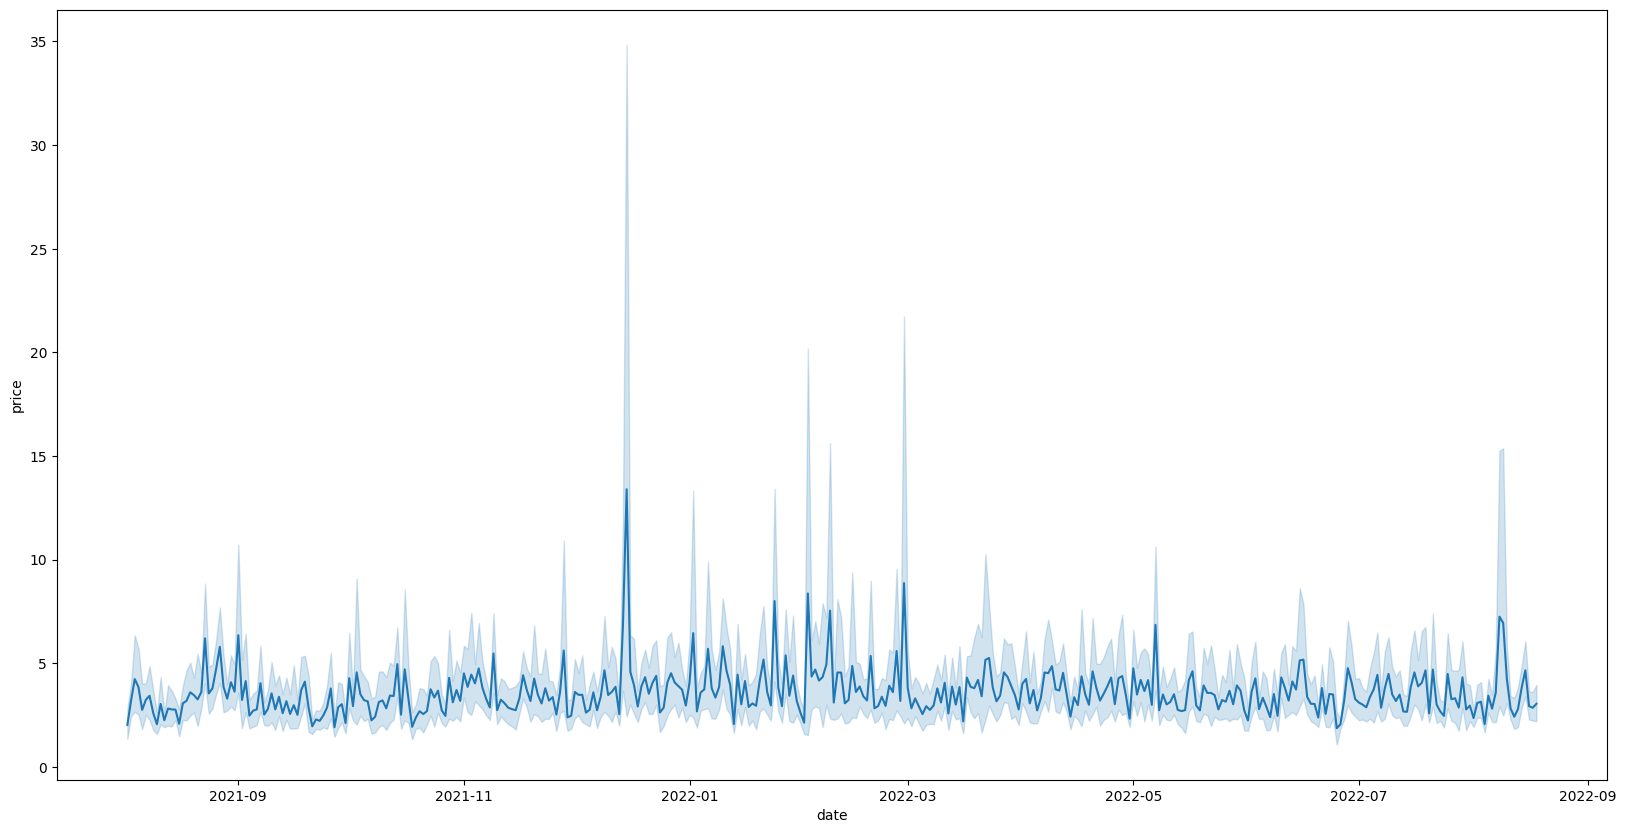

In [56]:
#¿Cómo varían los precios de los productos a lo largo del tiempo?
plt.figure(figsize=(20,10))
sns.lineplot(data=df_final2, x="date", y="price");

## Análisis de productos


In [57]:
# ¿Qué productos tienen más registros de precios?
# Contar cuántos registros de precios tiene cada producto
productos_mas_registrados = df_final2['name'].value_counts().reset_index()
productos_mas_registrados.columns = ['name', 'num_registros']

productos_mas_registrados = productos_mas_registrados.sort_values(by="num_registros", ascending=False)
# Mostrar los 10 productos con más registros de precios
print(productos_mas_registrados.head(10))


                                                 name  num_registros
0      BETRES gel de ducha rosa mosqueta bote 1000 ml              2
1   SCHOLL Gel activ plantillas profesional para h...              2
2   SERPIS aceitunas rellenas de anchoa pack 4 lat...              2
3              DIA cocktail frutos secos bolsa 500 gr              2
4             HS champú anticaspa classic bote 255 ml              2
5   DIA SUPER PACO friegasuelos aroma spa botella ...              2
6   DIA SUPER PACO friegasuelos aroma pino botella...              2
7           BONTE desodorante attraction spray 150 ml              2
16  GILLETTE Venus simply maquinilla desechable bo...              2
15  DIA SUPER PACO friegasuelos aroma limón botell...              2


In [58]:
df_final2['product_id'].unique()

array(['9e2fda45e63337294f2a604178823026',
       '244994c762813d38881cb118742152a2',
       '8a5398b602e44b93a0c0a4a7b9d22b84', ...,
       '09fd90e1a5719cf9906b65eedb14ce0f',
       'f25e7805007523eaa1c524f23c232c26',
       '01af8bbca86863c1c85df068d136ac11'], dtype=object)

In [59]:
df_final2['product_id'].nunique()


9496

In [60]:
#- ¿Cuántos productos distintos hay en el dataset?
# Contar el número de productos únicos
num_productos_distintos = df_final2['product_id'].unique()
num_productos_distintos = len(num_productos_distintos)

print(f"Número de productos distintos en el dataset: {num_productos_distintos}")


Número de productos distintos en el dataset: 9496


In [61]:
## - ¿Existen productos en el dataset de precios que no tienen información en el dataset de productos?
# Identificar los productos en cada dataset
productos_precios_set = set(df_final2['product_id'])
productos_info_set = set(df_precios['product_id'])

# Encontrar productos en precios que no están en productos_dia
productos_sin_info = productos_precios_set - productos_info_set

print(f"Número de productos en precios que no tienen información en productos_dia: {len(productos_sin_info)}")

# Convertir a DataFrame para visualización
productos_sin_info_df = pd.DataFrame(list(productos_sin_info), columns=['product_id'])

print(productos_sin_info_df.head(10))  # Mostrar los primeros 10 productos sin información

Número de productos en precios que no tienen información en productos_dia: 27
                         product_id
0  0aef64a59e9cb6fb6b8cd32ed2c4da9a
1  fd2c37f2b86164d90831575d17f8dac9
2  c4eb472dc4b8d46463388c96496c71bd
3  e12017ee1ec3426dfa0d5f390f8d6aeb
4  1989d81092b8220d1668c0aafed21796
5  75104080220d5094fd150d2e73d3744e
6  102ed86230845c074c41cab08adb56a4
7  87723bcc608ee90f68e205bcce30ab84
8  a3730de717d3e8eaf348f319a6ca324f
9  42e03712b67eb4d08553ffc72296e735


## Relación entre precios y unidades de medida


In [62]:
#- ¿Cuál es el precio medio por unidad de referencia de cada producto?

# Calcular el precio medio por unidad de referencia de cada producto
precio_medio_unidad = df_final2.groupby('reference_unit')['price'].mean().reset_index()
precio_medio_unidad = df_final2.rename(columns={'price': 'precio_medio'})

# Mostrar los resultados
print("Precio medio por unidad de referencia:")
print(precio_medio_unidad)

Precio medio por unidad de referencia:
         precio_medio  reference_price                        product_id  \
0                1.59             1.59  9e2fda45e63337294f2a604178823026   
10               3.99             0.11  244994c762813d38881cb118742152a2   
42               9.99             0.24  8a5398b602e44b93a0c0a4a7b9d22b84   
215              7.99             0.44  2cd7ea87b1963adb51d8e1295f6c14d3   
384              2.69             5.38  4abac3d30922f81012d7ae0c2cd955f2   
...               ...              ...                               ...   
1264332          2.75            13.75  33cd6d565efc2a1058151089366828ba   
1264335          2.55            12.75  3729369bcfc9c8b8a732c44a48145ea9   
1264337          0.52             1.58  09fd90e1a5719cf9906b65eedb14ce0f   
1264338          3.09            15.45  f25e7805007523eaa1c524f23c232c26   
1264361          8.29            16.58  01af8bbca86863c1c85df068d136ac11   

        reference_unit          insert_date supe

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=precio_medio_unidad, x='reference_unit', y='price', palette='viridis')
plt.title("Precio Medio por Unidad de Referencia")
plt.xlabel("Unidad de Referencia")
plt.ylabel("Precio Medio")
plt.show()

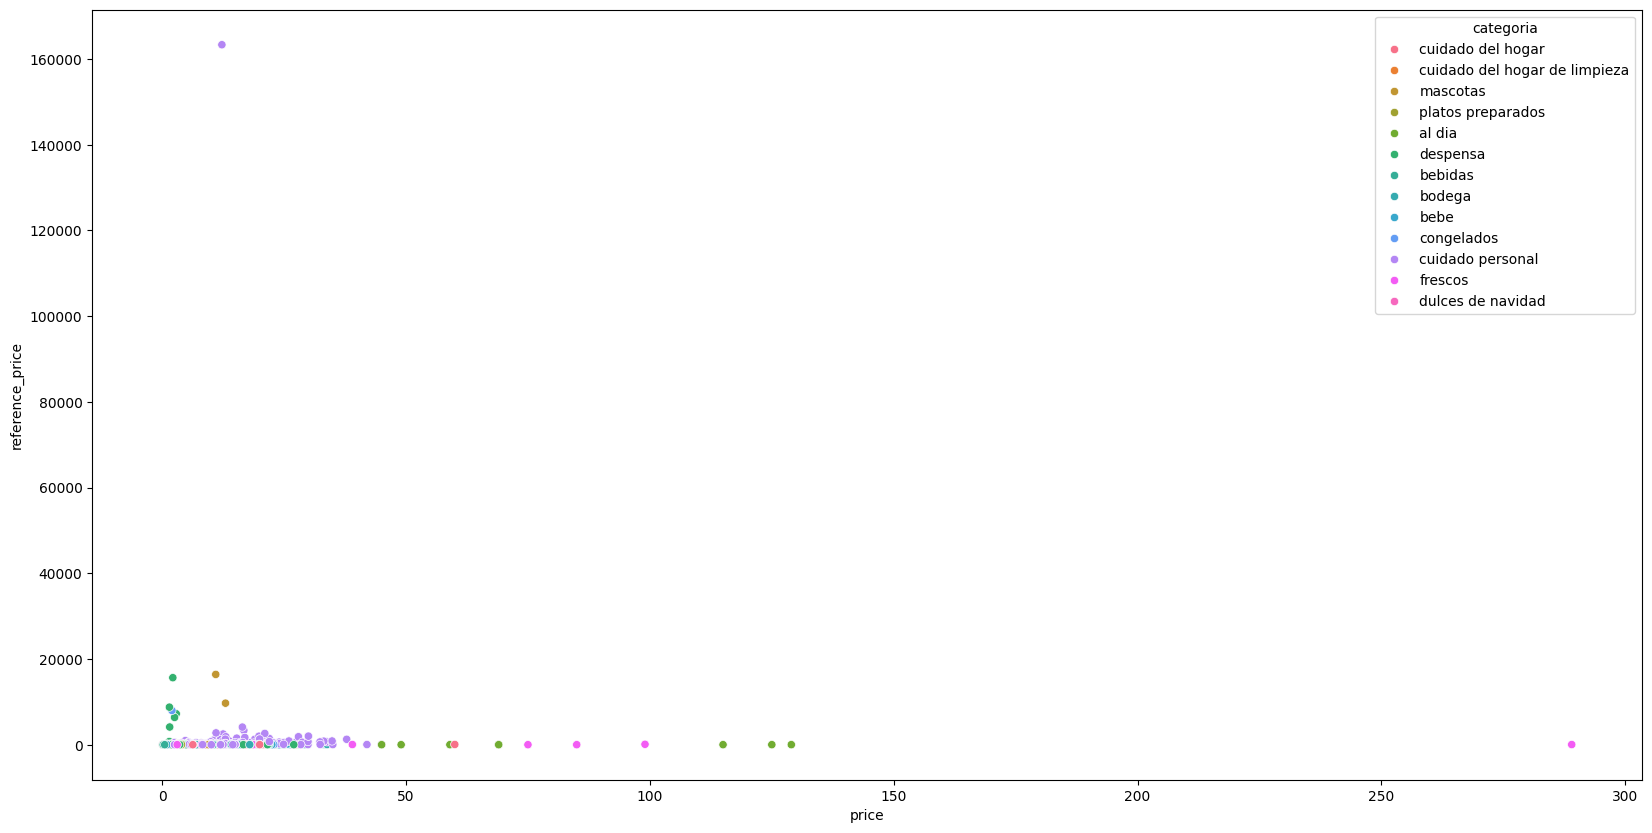

In [63]:
##Relación entre precios, referencia de precios y categorías
plt.figure(figsize=(20,10))
sns.scatterplot(data = df_final2, x = "price", y = "reference_price", hue = "categoria");

In [64]:
df2 = df_final2[df_final2["reference_price"] < 20000]
df2.head()

,price,reference_price,product_id,reference_unit,insert_date,supermarket,name,categoria,subcategoria,date,difference
0,1.59,1.59,9e2fda45e63337294f2a604178823026,ud,2021-08-14 00:00:00,dia-es,MISTOL lavavajillas mano original botella 900 ml,cuidado del hogar,lavavajillas,2021-08-14,0.00
10,3.99,0.11,244994c762813d38881cb118742152a2,ud,2021-08-22 00:00:00,dia-es,DIA lavavajillas máquina premium todo en uno e...,cuidado del hogar,lavavajillas,2021-08-22,-3.88
42,9.99,0.24,8a5398b602e44b93a0c0a4a7b9d22b84,ud,2021-10-23 00:00:00,dia-es,FAIRY lavavajillas máquina platinum azul en cá...,cuidado del hogar,lavavajillas,2021-10-23,-9.75
215,7.99,0.44,2cd7ea87b1963adb51d8e1295f6c14d3,ud,2022-07-03 00:00:00,dia-es,FAIRY lavavajillas máquina platinum plus limón...,cuidado del hogar,lavavajillas,2022-07-03,-7.55
384,2.69,5.38,4abac3d30922f81012d7ae0c2cd955f2,l,2022-02-07 00:00:00,dia-es,FAIRY lavavajillas mano concentrado aloe vera ...,cuidado del hogar,lavavajillas,2022-02-07,2.69


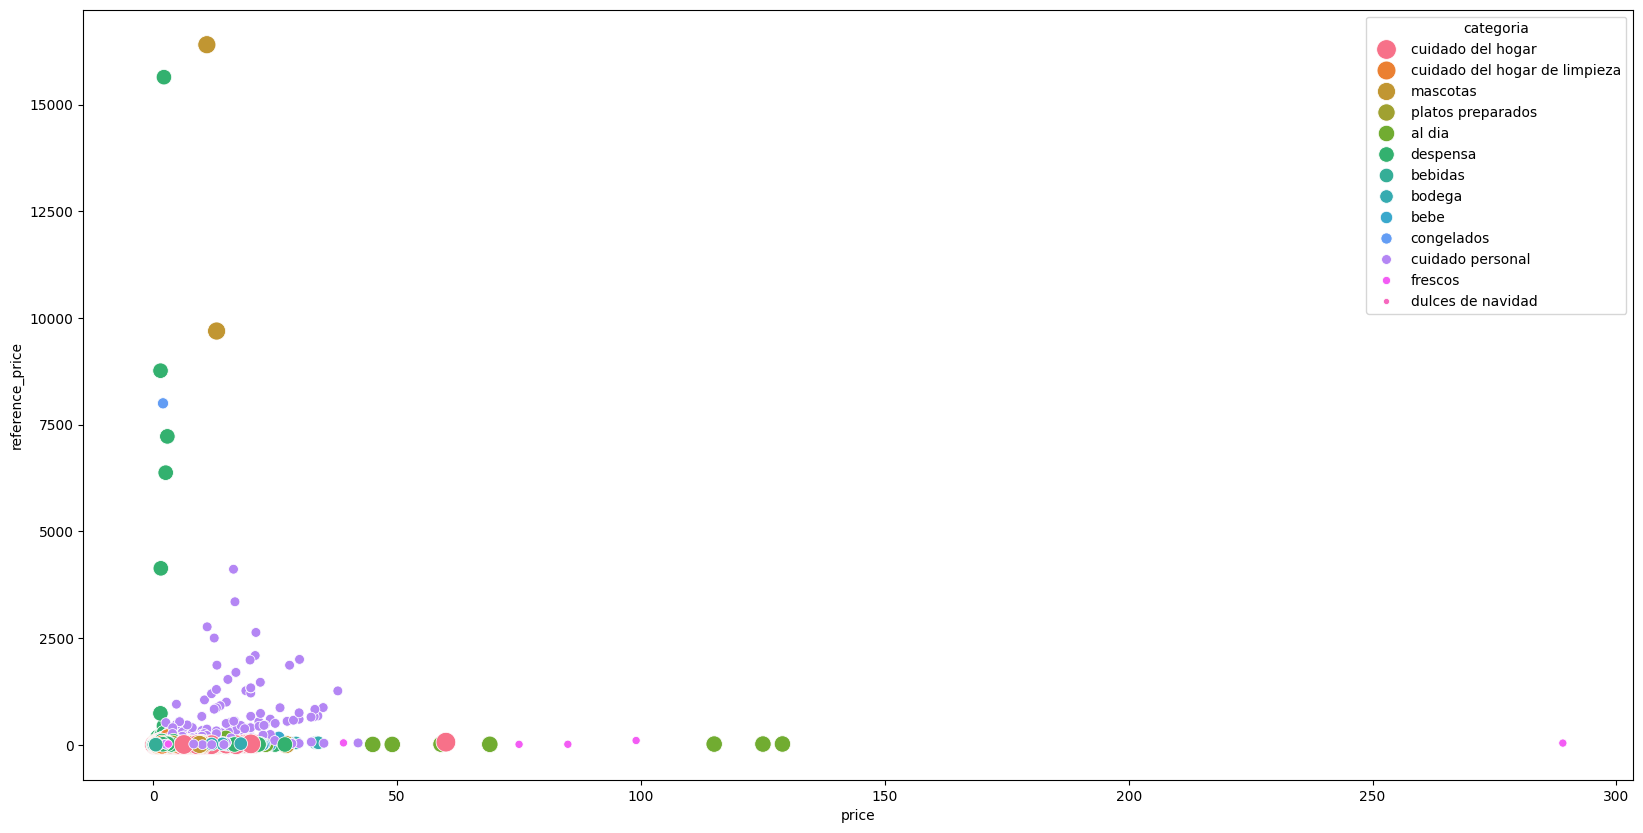

In [65]:
plt.figure(figsize=(20,10))
sns.scatterplot(data = df2, x = "price", y = "reference_price", hue = "categoria", size = "categoria",  sizes=(20, 200));

In [66]:
# analíticamente con numpy
np.corrcoef(df2["price"], df2["reference_price"])

array([[1.        , 0.09614447],
       [0.09614447, 1.        ]])

In [67]:
# analíticamente con pandas

df2[["price", "reference_price"]].corr()

,price,reference_price
price,1.000000,0.096144
reference_price,0.096144,1.000000
